# 5.6 — VAE - SBR Relationship

Objective: Systematically characterise the relationship between VAE latent dimensions and traditional SBR quantification.

What this notebook does:

- Identify the top latent dimension per SBR component
- Quantify how much of total SBR variance the VAE explains
- Analyse overlap between SBR-encoding dims and clinical dims
- Visualise the VAE-SBR relationship

## 1. Imports and Configuration

In [52]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import os
import warnings
warnings.filterwarnings('ignore')

In [53]:
# CONFIG
TRAIN_FILE     = '../../data/processed/clinical_merged/train_v3.csv'
SBR_CORR_FILE  = '../../results/correlation/correlation_sbr_train.csv'
SBR_VAL_FILE   = '../../results/correlation/correlation_sbr_val.csv'
CLIN_CORR_FILE = '../../results/correlation/correlation_train.csv'
CLIN_VAL_FILE  = '../../results/correlation/correlation_val.csv'
KL_FILE        = '../../data/baseline/kl_divergence.csv'
OUTPUT_DIR     = '../../results/correlation/'
FIGURES_DIR    = '../../results/figures/'
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

PATIENT_COL = 'PATNO'
LABEL_COL   = 'label'
N_FOLDS     = 5
RANDOM_STATE = 42

SBR_DIMS  = ['SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']
SBR_LABELS = {
    'SBR_XING_PC1': 'SBR PC1 (Overall dopamine)',
    'SBR_XING_PC2': 'SBR PC2 (Caudate vs Putamen)',
    'SBR_XING_PC3': 'SBR PC3 (Laterality)'
}

# Active dimensions from KL divergence
df_kl      = pd.read_csv(KL_FILE)
ACTIVE_DIMS = df_kl[df_kl['mean_kl'] > 0.05]['dimension'].tolist()

print(f"Active dimensions: {len(ACTIVE_DIMS)}")
print(f"SBR dimensions:    {len(SBR_DIMS)}")

Active dimensions: 111
SBR dimensions:    3


## 2. Load Data

In [54]:
# [LOAD-DATA]
df_train = pd.read_csv(TRAIN_FILE)

# Filter to rows with SBR data (69% subset)
df_sbr = df_train.dropna(subset=SBR_DIMS).copy()

# Load correlation results from notebook 5.1
df_sbr_corr     = pd.read_csv(SBR_CORR_FILE)
df_sbr_val      = pd.read_csv(SBR_VAL_FILE)
df_clin_corr    = pd.read_csv(CLIN_CORR_FILE)
df_clin_val     = pd.read_csv(CLIN_VAL_FILE)

print(f"=== Dataset ===")
print(f"Full train:  {len(df_train)} rows, {df_train[PATIENT_COL].nunique()} patients")
print(f"SBR subset:  {len(df_sbr)} rows, {df_sbr[PATIENT_COL].nunique()} patients")

print(f"\n=== Correlation results loaded ===")
print(f"SBR train:   {df_sbr_corr.shape}")
print(f"SBR val:     {df_sbr_val.shape}")
print(f"Clinical:    {df_clin_corr.shape}")

=== Dataset ===
Full train:  3085 rows, 1678 patients
SBR subset:  2135 rows, 1102 patients

=== Correlation results loaded ===
SBR train:   (111, 13)
SBR val:     (111, 4)
Clinical:    (111, 26)


## 3. Analysis

### 3.1 Analysis 1 — top latent dimension per SBR component.

What this does: For each SBR component, finds the top latent dimensions ranked by effect size (r²), showing which dimensions most strongly encode each aspect of dopamine signal.

In [55]:
print("=== Analysis 1: Top latent dimensions per SBR component ===\n")

for sbr_factor in SBR_DIMS:
    label = SBR_LABELS[sbr_factor]
    r2_col  = f'{sbr_factor}_r2'
    sig_col = f'{sbr_factor}_sig'
    val_col = f'{sbr_factor}_validated'

    if r2_col not in df_sbr_corr.columns:
        print(f"{label}: not found in correlation results")
        continue

    # Merge train and val results
    df_merged = df_sbr_corr[['dimension', r2_col, sig_col]].merge(
        df_sbr_val[['dimension', val_col]],
        on='dimension', how='left'
    )


    # print(df_merged) 

    # Filter to significant and validated
    df_sig = df_merged[df_merged[sig_col] == True].copy()
    df_val = df_merged[df_merged[val_col] == True].copy()

    # Sort by effect size
    df_sig = df_sig.sort_values(r2_col, ascending=False)

    print(f"{label}")
    print(f"  Significant: {len(df_sig)} dims  |  Validated: {len(df_val)} dims")
    print(f"  Top 5 dimensions:")
    print(f"  {'Dimension':<15} {'r²':>8} {'Validated':>12}")
    print(f"  {'-'*37}")
    for _, row in df_sig.head(5).iterrows():
        validated = '✓' if row[val_col] else '✗'
        print(f"  {row['dimension']:<15} {row[r2_col]:>8.3f} {validated:>12}")
    print()

=== Analysis 1: Top latent dimensions per SBR component ===

SBR PC1 (Overall dopamine)
  Significant: 51 dims  |  Validated: 33 dims
  Top 5 dimensions:
  Dimension             r²    Validated
  -------------------------------------
  latent_132         0.811            ✓
  latent_150         0.295            ✓
  latent_225         0.251            ✓
  latent_151         0.166            ✓
  latent_113         0.090            ✓

SBR PC2 (Caudate vs Putamen)
  Significant: 59 dims  |  Validated: 44 dims
  Top 5 dimensions:
  Dimension             r²    Validated
  -------------------------------------
  latent_114         0.435            ✓
  latent_106         0.286            ✓
  latent_141         0.187            ✓
  latent_15          0.145            ✓
  latent_132         0.137            ✓

SBR PC3 (Laterality)
  Significant: 59 dims  |  Validated: 50 dims
  Top 5 dimensions:
  Dimension             r²    Validated
  -------------------------------------
  latent_173         0

### 3.2 Analysis 2 — how much total SBR variance can the VAE explain?
 How much of total SBR variance can the full VAE representation explain? We use Ridge regression with 5-fold patient-stratified CV to predict each SBR component from all active latent dims. This answers: how well does the VAE capture SBR overall?

In [56]:

def predict_cv(df, feature_cols, target_col, patient_col=PATIENT_COL):
    data = df[feature_cols + [target_col, patient_col]].dropna().copy()
    if len(data) < 20:
        return np.nan, np.nan, 0

    unique_patients = data[patient_col].unique()
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    r2_scores = []

    for train_idx, val_idx in kf.split(unique_patients):
        train_pats = unique_patients[train_idx]
        val_pats   = unique_patients[val_idx]
        train_data = data[data[patient_col].isin(train_pats)]
        val_data   = data[data[patient_col].isin(val_pats)]

        X_train = train_data[feature_cols].values
        X_val   = val_data[feature_cols].values
        y_train = train_data[target_col].values
        y_val   = val_data[target_col].values

        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)

        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        r2_scores.append(r2_score(y_val, model.predict(X_val)))

    return np.mean(r2_scores), np.std(r2_scores), len(data)

print("=== Analysis 2: Total SBR variance explained by VAE ===\n")
print(f"{'SBR Component':<30} {'R² (5-fold CV)':>15} {'Std':>8} {'n':>6}")
print("-" * 62)

for sbr_factor in SBR_DIMS:
    r2, std, n = predict_cv(df_sbr, ACTIVE_DIMS, sbr_factor)
    label = SBR_LABELS[sbr_factor]
    print(f"  {label:<28} {r2:>15.3f} {std:>8.3f} {n:>6}")

=== Analysis 2: Total SBR variance explained by VAE ===

SBR Component                   R² (5-fold CV)      Std      n
--------------------------------------------------------------
  SBR PC1 (Overall dopamine)             0.963    0.002   2135
  SBR PC2 (Caudate vs Putamen)           0.855    0.010   2135
  SBR PC3 (Laterality)                   0.893    0.005   2135


### 3.3 Analysis 3 — Overlap Between SBR and Clinical Dimensions

What this does: Checks whether the dimensions that encode SBR are the same ones that encode clinical scores (UPDRS, MoCA, H&Y) — or whether they are different dimensions encoding different information.

Why this matters: If SBR dims and clinical dims are the same, the VAE is just learning dopamine signal and nothing else. If they are different, the VAE has learned multiple independent axes of variation — which is a stronger and more interesting finding.

In [57]:

# Get validated dims for each factor
def get_validated_dims(df_val, factor):
    col = f'{factor}_validated'
    if col not in df_val.columns:
        return set()
    return set(df_val[df_val[col] == True]['dimension'].tolist())

# SBR validated dims
sbr_pc1_dims = get_validated_dims(df_sbr_val, 'SBR_XING_PC1')
sbr_pc2_dims = get_validated_dims(df_sbr_val, 'SBR_XING_PC2')
sbr_pc3_dims = get_validated_dims(df_sbr_val, 'SBR_XING_PC3')
sbr_all_dims = sbr_pc1_dims | sbr_pc2_dims | sbr_pc3_dims

# Clinical validated dims
updrs_dims = get_validated_dims(df_clin_val, 'UPDRS3_TOTAL')
moca_dims  = get_validated_dims(df_clin_val, 'MOCA_TOTAL')
hy_dims    = get_validated_dims(df_clin_val, 'HOEHN_YAHR')
clin_dims  = updrs_dims | moca_dims | hy_dims

# Overlap analysis
overlap     = sbr_all_dims & clin_dims
sbr_only    = sbr_all_dims - clin_dims
clin_only   = clin_dims - sbr_all_dims
neither     = set(ACTIVE_DIMS) - sbr_all_dims - clin_dims

print("=== Analysis 3: Overlap between SBR and clinical dimensions ===\n")
print(f"SBR validated dims (PC1+PC2):     {len(sbr_all_dims)}")
print(f"Clinical validated dims:           {len(clin_dims)}")
print(f"  UPDRS-III:                       {len(updrs_dims)}")
print(f"  MoCA:                            {len(moca_dims)}")
print(f"  H&Y:                             {len(hy_dims)}")

print(f"\nOverlap (both SBR and clinical):   {len(overlap)}")
print(f"SBR only (not clinical):           {len(sbr_only)}")
print(f"Clinical only (not SBR):           {len(clin_only)}")
print(f"Neither:                           {len(neither)}")

print(f"\nOverlapping dimensions: {sorted(overlap)}")
print(f"\nSBR-only dimensions:    {sorted(sbr_only)}")
print(f"\nClinical-only dims:     {sorted(clin_only)}")

=== Analysis 3: Overlap between SBR and clinical dimensions ===

SBR validated dims (PC1+PC2):     83
Clinical validated dims:           63
  UPDRS-III:                       39
  MoCA:                            14
  H&Y:                             57

Overlap (both SBR and clinical):   50
SBR only (not clinical):           33
Clinical only (not SBR):           13
Neither:                           15

Overlapping dimensions: ['latent_10', 'latent_102', 'latent_106', 'latent_11', 'latent_111', 'latent_112', 'latent_113', 'latent_114', 'latent_116', 'latent_132', 'latent_133', 'latent_147', 'latent_15', 'latent_150', 'latent_151', 'latent_169', 'latent_173', 'latent_185', 'latent_192', 'latent_20', 'latent_203', 'latent_206', 'latent_208', 'latent_214', 'latent_216', 'latent_218', 'latent_222', 'latent_225', 'latent_227', 'latent_228', 'latent_232', 'latent_234', 'latent_237', 'latent_245', 'latent_3', 'latent_31', 'latent_41', 'latent_51', 'latent_55', 'latent_66', 'latent_69', 'late

### 3.3.1 Visualize

In [58]:
%pip install matplotlib-venn

Note: you may need to restart the kernel to use updated packages.


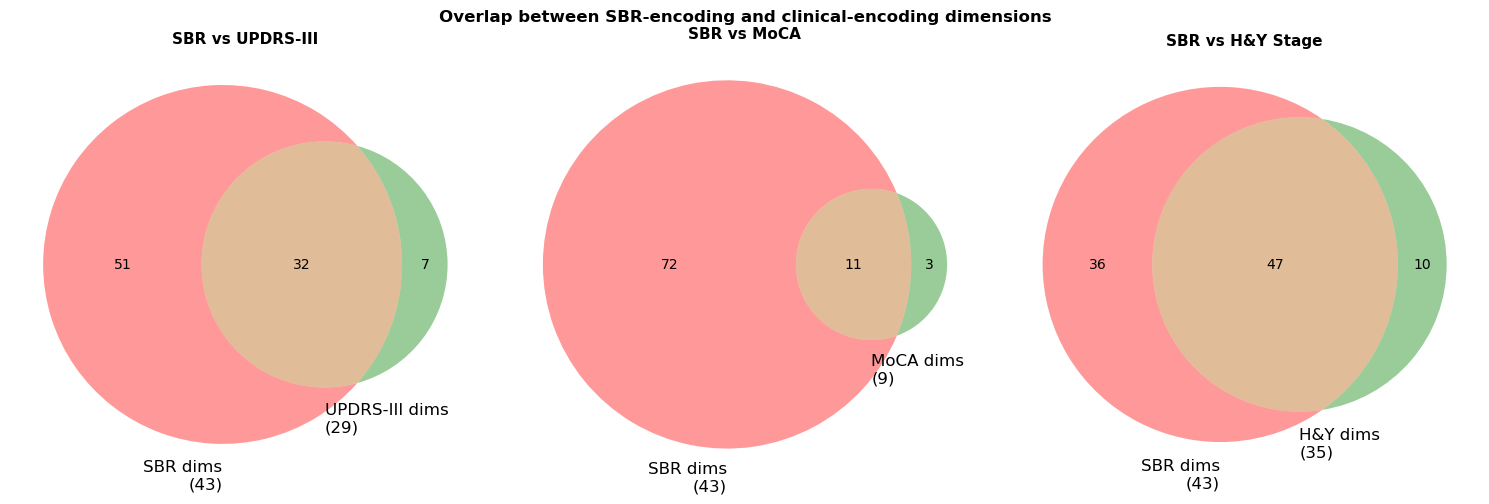

Saved: ../../results/figures//venn_sbr_clinical.png


In [ ]:
# [ANALYSIS-3-VENN]
from matplotlib_venn import venn2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# SBR vs UPDRS
venn2([sbr_all_dims, updrs_dims],
      set_labels=('SBR dims\n(43)', 'UPDRS-III dims\n(29)'),
      ax=axes[0])
axes[0].set_title('SBR vs UPDRS-III', fontsize=11, fontweight='bold')

# SBR vs MoCA
venn2([sbr_all_dims, moca_dims],
      set_labels=('SBR dims\n(43)', 'MoCA dims\n(9)'),
      ax=axes[1])
axes[1].set_title('SBR vs MoCA', fontsize=11, fontweight='bold')

# SBR vs H&Y
venn2([sbr_all_dims, hy_dims],
      set_labels=('SBR dims\n(43)', 'H&Y dims\n(35)'),
      ax=axes[2])
axes[2].set_title('SBR vs H&Y Stage', fontsize=11, fontweight='bold')

fig.suptitle('Overlap between SBR-encoding and clinical-encoding dimensions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
path = f'{FIGURES_DIR}/venn_sbr_clinical.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")